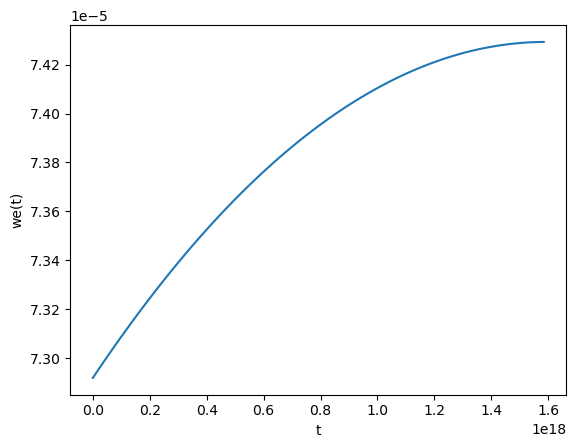

In [64]:
## Joshua Treece
# Graphs Earth's angular spin velocity as a function of time
# considering tidal effects on lunar regression.

from math import sin, cos, tan, sqrt, factorial
from numpy import arange
from pylab import plot,xlabel,ylabel,show

# constants
G = 6.67430 * 10**(-11)  #Gravitational Constant (m^3kg^-1s^-2)
Me = 5.97219 * 10**24    #Mass of the Earth (kg)
Mm = 7.34767 * 10**22    #Mass of the Moon (kg)
I_e = 8 * 10**37         #Earth's moment of inertia
I_m = 8.86 * 10**34      #Moon's moment of inertia
Re = 6.371 * 10**6       #Earth's mean radius

def main():
    # initial conditions
    t = 0                   #t = 0 durring March 2014
    xwe = 7.292 * 10**(-5)  #Earth's angular velocity
    xEp = 0.4091            #Earth's obliquitiy
    xr = 3.844 * 10**9      #Moon-Earth distance
    xwm = 2.662 * 10**(-6)  #Lunar orbital angular velocity
    xe = 0.0549             #Lunar orbital excentricity
    xIm = 0.0898            #Lunar orbital inclination
    
    t0 = 0
    t1 = 1.6 * 10**18
    N = 100
    h = (t1-t0)/N
    
    tpoints = arange(t0,t1,h)
    xpoints = []
    for t in tpoints:
        xpoints.append(xwe)
        
        k1we = h * dwe(xwe, xEp, xr, xwm, xe, xIm, t)
        #print("k1we:", k1we)
        #print("xe:",xe)
        k1Ep = h * dEp(xwe, xEp, xr, xwm, xe, xIm, t)
        #print("k1Ep:", k1Ep)
        #print("xe:",xe)
        k1r  = h *  dr(xwe, xEp, xr, xwm, xe, xIm, t)
        #print("k1r:", k1r)
        #print("xe:",xe)
        k1wm = h * dwm(xwe, xEp, xr, xwm, xe, xIm, t)
        #print("k1wm:", k1wm)
        #print("xe:",xe)
        k1e  = h *  de(xwe, xEp, xr, xwm, xe, xIm, t)
        #print("k1e:", k1e)
        #print("xe:",xe)
        k1Im = h * dIm(xwe, xEp, xr, xwm, xe, xIm, t)
        #print("k1Im:", k1Im)
        #print("xe:",xe)
        
        k2we = h * dwe(xwe+0.5*k1we, xEp+0.5*k1Ep, xr+0.5*k1r, xwm+0.5*k1wm, xe+0.5*k1e, xIm+0.5*k1Im, t+0.5*h)
        k2Ep = h * dEp(xwe+0.5*k1we, xEp+0.5*k1Ep, xr+0.5*k1r, xwm+0.5*k1wm, xe+0.5*k1e, xIm+0.5*k1Im, t+0.5*h)
        k2r  = h *  dr(xwe+0.5*k1we, xEp+0.5*k1Ep, xr+0.5*k1r, xwm+0.5*k1wm, xe+0.5*k1e, xIm+0.5*k1Im, t+0.5*h)
        k2wm = h * dwm(xwe+0.5*k1we, xEp+0.5*k1Ep, xr+0.5*k1r, xwm+0.5*k1wm, xe+0.5*k1e, xIm+0.5*k1Im, t+0.5*h)
        k2e  = h *  de(xwe+0.5*k1we, xEp+0.5*k1Ep, xr+0.5*k1r, xwm+0.5*k1wm, xe+0.5*k1e, xIm+0.5*k1Im, t+0.5*h)
        k2Im = h * dIm(xwe+0.5*k1we, xEp+0.5*k1Ep, xr+0.5*k1r, xwm+0.5*k1wm, xe+0.5*k1e, xIm+0.5*k1Im, t+0.5*h)
    
        k3we = h * dwe(xwe+0.5*k2we, xEp+0.5*k2Ep, xr+0.5*k2r, xwm+0.5*k2wm, xe+0.5*k2e, xIm+0.5*k2Im, t+0.5*h)
        k3Ep = h * dEp(xwe+0.5*k2we, xEp+0.5*k2Ep, xr+0.5*k2r, xwm+0.5*k2wm, xe+0.5*k2e, xIm+0.5*k2Im, t+0.5*h)
        k3r  = h *  dr(xwe+0.5*k2we, xEp+0.5*k2Ep, xr+0.5*k2r, xwm+0.5*k2wm, xe+0.5*k2e, xIm+0.5*k2Im, t+0.5*h)
        k3wm = h * dwm(xwe+0.5*k2we, xEp+0.5*k2Ep, xr+0.5*k2r, xwm+0.5*k2wm, xe+0.5*k2e, xIm+0.5*k2Im, t+0.5*h)
        k3e  = h *  de(xwe+0.5*k2we, xEp+0.5*k2Ep, xr+0.5*k2r, xwm+0.5*k2wm, xe+0.5*k2e, xIm+0.5*k2Im, t+0.5*h)
        k3Im = h * dIm(xwe+0.5*k2we, xEp+0.5*k2Ep, xr+0.5*k2r, xwm+0.5*k2wm, xe+0.5*k2e, xIm+0.5*k2Im, t+0.5*h)
        
        k4we = h * dwe(xwe+k3we, xEp+k3Ep, xr+k3r, xwm+k3wm, xe+k3e, xIm+k3Im, t+h)
        k4Ep = h * dEp(xwe+k3we, xEp+k3Ep, xr+k3r, xwm+k3wm, xe+k3e, xIm+k3Im, t+h)
        k4r  = h *  dr(xwe+k3we, xEp+k3Ep, xr+k3r, xwm+k3wm, xe+k3e, xIm+k3Im, t+h)
        k4wm = h * dwm(xwe+k3we, xEp+k3Ep, xr+k3r, xwm+k3wm, xe+k3e, xIm+k3Im, t+h)
        k4e  = h *  de(xwe+k3we, xEp+k3Ep, xr+k3r, xwm+k3wm, xe+k3e, xIm+k3Im, t+h)
        k4Im = h * dIm(xwe+k3we, xEp+k3Ep, xr+k3r, xwm+k3wm, xe+k3e, xIm+k3Im, t+h)
        
        xwe += (k1we+2*k2we+2*k3we+k4we)/6
        xEp += (k1Ep+2*k2Ep+2*k3Ep+k4Ep)/6
        xr  += (k1r+2*k2r+2*k3r+k4r)/6
        xwm += (k1wm+2*k2wm+2*k3wm+k4wm)/6
        xe  += (k1e+2*k2e+2*k3e+k4e)/6
        xIm += (k1Im+2*k2Im+2*k3Im+k4Im)/6
    
    plot(tpoints,xpoints)
    xlabel("time (s)")
    ylabel("Earth's Angular Velocity (rad/s)")
    show()

##
# this function returns the rate of change of Earth's angular velocity.
# @param we - Earth's current angular velocity
# @param Ep - Earth's current obliquity
# @param r  - the current Earth-Moon distance
# @param wm - the current lunar angular velocity
# @param e  - the current lunar orbital excentricity
# @param Im - the current lunar orbital inclination
# @param t  - the instant in time
# @return the instantaneous change in Earth's angular velocity.
def dwe(we, Ep, r, wm, e, Im, t):
    #print("dwe")
    return -we/tan(Ep) * dEp(we, Ep, r, wm, e, Im, t)

##
# this function returns the rate of change of Earth's obliquity.
# @param we - Earth's current angular velocity
# @param Ep - Earth's current obliquity
# @param r  - the current Earth-Moon distance
# @param wm - the current lunar angular velocity
# @param e  - the current lunar orbital excentricity
# @param Im - the current lunar orbital inclination
# @param t  - the instant in time
# @return the instantaneous change in Earth's obliquity.
def dEp(we, Ep, r, wm, e, Im, t):
    #print("dEp")
    return (G*Me*Mm)/(I_e*sqrt(G*(Me+Mm))) * sin(Ep)/we * cos(I_m) * (sqrt(1 - e**2)/(2*sqrt(r)) * dr(we, Ep, r, wm, e, Im, t) - e*sqrt(r)/sqrt(1 - e**2) * de(we, Ep, r, wm, e, Im, t))

##
# this function returns the rate of change of the Earth-Moon distance.
# @param we - Earth's current angular velocity
# @param Ep - Earth's current obliquity
# @param r  - the current Earth-Moon distance
# @param wm - the current lunar angular velocity
# @param e  - the current lunar orbital excentricity
# @param Im - the current lunar orbital inclination
# @param t  - the instant in time
# @param l  - the critical spherical harmonic degree, default set to 2 for tidal studies
# @return the instantaneous change in Earth-Moon distance.
def dr(we, Ep, r, wm, e, Im, t, l = 2, m = 2): 
    #print("dr")
    if l == 2:
        kl = 0.3               #love number moderate effect
    elif l == 3:
        kl = 0.09              #love number minimal effect
    else:
        kl = 0                 #love number negledgable effect
    kronecker_delta = 0
    
    s = 0
    if m == 0: Kronecker_delta = 1 
    for p in range(0, l+1):
         for q in range(-l, l+1):
            #Calculating Klm
            Klm = G*Mm*kl/sqrt(G*(Me+Mm)*r) * (Re/r)**(2*l+1) * factorial(l-m)/factorial(l+m) * (2 - kronecker_delta)
             
            #Calculating Flmp
            Flmp = 3/2 * sin(Im)**2
            #Calculating Glpq
            B = e/(1+sqrt(1-e**2))
            Gs = 0
            for k in range(0, l+2):
                Plpqk = 0
                Qlpqk = 0
                if l+1-2*p+q >= 0 and l+1-2*p+q-k >= 0: Plpqk = factorial(l+1-2*p+q)/(factorial(k)*factorial(l+1-2*p+q-k))
                if l-1+2*p-q >= 0 and l-1+2*p-q-k >= 0: Qlpqk = factorial(l-1+2*p-q)/(factorial(k)*factorial(l-1+2*p-q-k))
                Gs += Plpqk * Qlpqk * B**(2*k)
            Glpq = (-1)**abs(q) * (1+B**2)**l * B**abs(q) * Gs
                
            #gathering the sum
            s += Klm * sqrt(1-e**2)/(r*e) * Flmp**2 * Glpq**2
    return s

##
# this function returns the rate of change of lunar orbital angular velocity.
# @param we - Earth's current angular velocity
# @param Ep - Earth's current obliquity
# @param r  - the current Earth-Moon distance
# @param wm - the current lunar angular velocity
# @param e  - the current lunar orbital excentricity
# @param Im - the current lunar orbital inclination
# @param t  - the instant in time
# @return the instantaneous change in lunar orbital angular velocity.
def dwm(we, Ep, r, wm, e, Im, t):
    #print("dwm")
    return -3*wm/(2*r) * dr(we, Ep, r, wm, e, Im, t)

##
# this function returns the rate of change of lunar orbital excentricity.
# @param we - Earth's current angular velocity
# @param Ep - Earth's current obliquity
# @param r  - the current Earth-Moon distance
# @param wm - the current lunar angular velocity
# @param e  - the current lunar orbital excentricity
# @param Im - the current lunar orbital inclination
# @param t  - the instant in time
# @param l  - the critical spherical harmonic degree, default set to 2 for tidal studies
# @param m  - the critical spherical harmonic order, default set to 2 for tidal studies
# @return the instantaneous change in lunar orbital excentricity.
def de(we, Ep, r, wm, e, Im, t, l = 2, m = 2): 
    #print("de")
    if l == 2:
        kl = 0.3               #love number moderate effect
        philmpq = 0.02408554   #phase lag average (rad)
    elif l == 3:
        kl = 0.09              #love number minimal effect
        philmpq = 0.001
    else:
        kl = 0                 #love number negledgable effect
        philmpq = 0
    kronecker_delta = 0
    
    s = 0
    if m == 0: Kronecker_delta = 1 
    for p in range(0, l+1):
        for q in range(-l, l+1):
            #Calculating Klm
            Klm = G*Mm*kl/sqrt(G*(Me+Mm)*r) * (Re/r)**(2*l+1) * factorial(l-m)/factorial(l+m) * (2 - kronecker_delta)
             
            #Calculating Flmp
            Flmp = 3/2 * sin(Im)**2
            
            #Calculating Glpq
            B = e/(1+sqrt(1-e**2))
            Gs = 0
            for k in range(0, l+2):
                Plpqk = 0
                Qlpqk = 0
                if l+1-2*p+q >= 0 and l+1-2*p+q-k >= 0: Plpqk = factorial(l+1-2*p+q)/(factorial(k)*factorial(l+1-2*p+q-k))
                if l-1+2*p-q >= 0 and l-1+2*p-q-k >= 0: Qlpqk = factorial(l-1+2*p-q)/(factorial(k)*factorial(l-1+2*p-q-k))
                Gs += Plpqk * Qlpqk * B**(2*k)
            Glpq = (-1)**abs(q) * (1+B**2)**l * B**abs(q) * Gs
        
            #gathering the sum
            s += 2*Klm * Flmp**2 * Glpq**2 * (l-2*2+q)*sin(philmpq)
    return s

##
# this function returns the rate of change of lunar orbital inclination.
# @param we - Earth's current angular velocity
# @param Ep - Earth's current obliquity
# @param r  - the current Earth-Moon distance
# @param wm - the current lunar angular velocity
# @param e  - the current lunar orbital excentricity
# @param Im - the current lunar orbital inclination
# @param t  - the instant in time
# @return the instantaneous change in lunar orbital inclination.
def dIm(we, Ep, r, wm, e, Im, t):
    #print("dIm")
    return -sin(Im)*(1/(2*r) * dr(we, Ep, r, wm, e, Im, t) - e/(1-e**2) * de(we, Ep, r, wm, e, Im, t))

main()